# AML Transaction Monitoring Analysis

## Business Question
Can we identify suspicious transaction patterns in a dataset of 
5 million transactions — where only 0.10% are flagged as 
money laundering?

This mirrors the real challenge faced by analysts at banks and 
financial institutions every day. The goal is not just to find 
suspicious transactions — but to understand the patterns and 
behaviours that make them suspicious.

---

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv('../data/raw/HI-Small_Trans.csv')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst look:")
df.head()

Rows: 5078345
Columns: 11

Column names:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

First look:


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nLaundering breakdown:")
print(df['Is Laundering'].value_counts())
print(f"\nSuspicious rate: {df['Is Laundering'].mean() * 100:.2f}%") # Calculate and print the percentage of suspicious transactions

Missing values:
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

Data types:
Timestamp                 str
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
Is Laundering           int64
dtype: object

Laundering breakdown:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

Suspicious rate: 0.10%




## The Challenge
- **5,078,345** total transactions
- Only **0.10%** flagged as suspicious — roughly 5,000 transactions
- This is called a highly imbalanced dataset
- A naive model that flags nothing as suspicious would be 99.90% 
  accurate — but completely useless

---

In [7]:
print("Payment formats:")
print(df['Payment Format'].value_counts())

print("\nTop sending banks:")
print(df['From Bank'].value_counts().head(10))

print("\nCurrencies used:")
print(df['Payment Currency'].value_counts())

Payment formats:
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64

Top sending banks:
From Bank
70     449859
10      81629
12      79754
1       62211
15      52511
220     52417
20      41008
3       38413
7       31086
211     30451
Name: count, dtype: int64

Currencies used:
Payment Currency
US Dollar            1895172
Euro                 1168297
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146066
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            70703
Name: count, dtype: int64


In [8]:
# Rename columns to be cleaner and more readable
df.columns = ['timestamp', 'from_bank', 'from_account', 
              'to_bank', 'to_account', 'amount_received',
              'receiving_currency', 'amount_paid', 
              'payment_currency', 'payment_format', 
              'is_laundering']

# Convert timestamp to datetime so we can extract hour, day etc
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour of day from timestamp
df['hour'] = df['timestamp'].dt.hour

# Extract day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Flag where payment and receiving currency differ
# This is a classic AML red flag - currency conversion mid transaction
df['currency_change'] = (df['payment_currency'] != df['receiving_currency']).astype(int)

print("Cleaning done ✓")
print(df.dtypes)

Cleaning done ✓
timestamp             datetime64[us]
from_bank                      int64
from_account                     str
to_bank                        int64
to_account                       str
amount_received              float64
receiving_currency               str
amount_paid                  float64
payment_currency                 str
payment_format                   str
is_laundering                  int64
hour                           int32
day_of_week                    int32
currency_change                int64
dtype: object


Comparing suspicious vs normal transactions side by side

In [9]:
# Split into two groups
normal = df[df['is_laundering'] == 0]
suspicious = df[df['is_laundering'] == 1]

print("Normal transactions:", len(normal))
print("Suspicious transactions:", len(suspicious))

print("\n--- Amount Paid ---")
print("Normal avg:", round(normal['amount_paid'].mean(), 2))
print("Suspicious avg:", round(suspicious['amount_paid'].mean(), 2))

print("\n--- Currency Change ---")
print("Normal currency change %:", round(normal['currency_change'].mean() * 100, 2))
print("Suspicious currency change %:", round(suspicious['currency_change'].mean() * 100, 2))

print("\n--- Payment Format ---")
print("Normal:")
print(normal['payment_format'].value_counts(normalize=True).mul(100).round(2))
print("\nSuspicious:")
print(suspicious['payment_format'].value_counts(normalize=True).mul(100).round(2))

Normal transactions: 5073168
Suspicious transactions: 5177

--- Amount Paid ---
Normal avg: 4477000.04
Suspicious avg: 36135310.41

--- Currency Change ---
Normal currency change %: 1.42
Suspicious currency change %: 0.0

--- Payment Format ---
Normal:
payment_format
Cheque          36.74
Credit Card     26.08
ACH             11.75
Cash             9.67
Reinvestment     9.48
Wire             3.39
Bitcoin          2.88
Name: proportion, dtype: float64

Suspicious:
payment_format
ACH            86.59
Cheque          6.26
Credit Card     3.98
Cash            2.09
Bitcoin         1.08
Name: proportion, dtype: float64


### Findings at the first glance 

**Average Transaction Amount**
- Normal: ~4.4mln
- Suspicious: ~36mln (**8x higher than normal transactions**)

**Currency Change**
- Normal: 1.42% involve a currency change 
- Suspicious: 0.0% none of them change currency 

The second one is counterintuitive - you'd expect money launderers to change currency to hide the trail. But this actually makes sense in this dataset - the laundering pattern here is high value same-currency transfers, moving huge amounts quickly without drawing attention through currency conversion.

## Charts

### **1. Transactions amount distribution: normal vs suspicious**

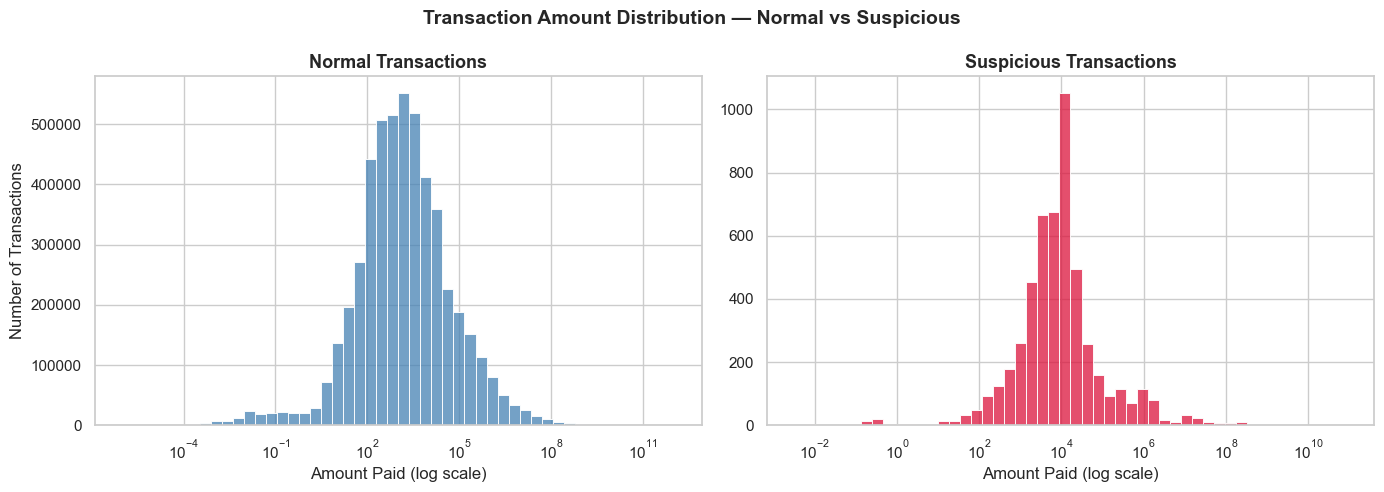

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(normal['amount_paid'], color='steelblue', 
             bins=50, ax=axes[0], log_scale=True)
axes[0].set_title('Normal Transactions', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount Paid (log scale)')
axes[0].set_ylabel('Number of Transactions')

sns.histplot(suspicious['amount_paid'], color='crimson', 
             bins=50, ax=axes[1], log_scale=True)
axes[1].set_title('Suspicious Transactions', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount Paid (log scale)')
axes[1].set_ylabel('')

fig.suptitle('Transaction Amount Distribution — Normal vs Suspicious', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/01_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight — Transaction Amount Distribution

The log scale reveals a clear difference in transaction size 
between normal and suspicious activity:

- **Normal transactions** are concentrated between **$100 and 
  $1,000** — consistent with everyday legitimate payments
- **Suspicious transactions** cluster significantly higher, 
  peaking around **$10,000 to $100,000**
- Both distributions have long right tails — but suspicious 
  transactions extend much further, with some reaching 
  into the billions

> **AML takeaway:** Transaction amount alone is not enough to 
> flag suspicious activity — but amounts consistently above 
> $10,000 are a meaningful red flag worth investigating further.

---

### **2. Suspicious Activity by Hour of Day**

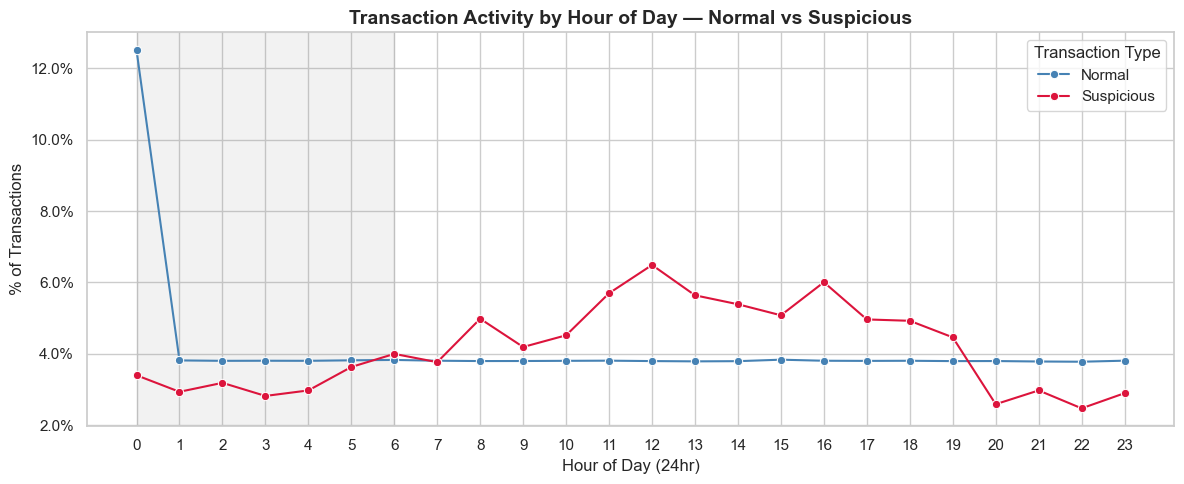

In [23]:
# Count transactions by hour for each group
normal_hours = normal.groupby('hour').size().reset_index(name='count')
normal_hours['type'] = 'Normal'

suspicious_hours = suspicious.groupby('hour').size().reset_index(name='count')
suspicious_hours['type'] = 'Suspicious'

# Normalize so we can compare fairly despite different group sizes
normal_hours['pct'] = normal_hours['count'] / normal_hours['count'].sum() * 100
suspicious_hours['pct'] = suspicious_hours['count'] / suspicious_hours['count'].sum() * 100

# Combine into one dataframe for plotting
hours_combined = pd.concat([normal_hours, suspicious_hours])

normal_hours = normal.groupby('hour').size().reset_index(name='count')
normal_hours['type'] = 'Normal'

suspicious_hours = suspicious.groupby('hour').size().reset_index(name='count')
suspicious_hours['type'] = 'Suspicious'

normal_hours['pct'] = normal_hours['count'] / normal_hours['count'].sum() * 100
suspicious_hours['pct'] = suspicious_hours['count'] / suspicious_hours['count'].sum() * 100

hours_combined = pd.concat([normal_hours, suspicious_hours])

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=hours_combined, x='hour', y='pct', 
             hue='type', marker='o',
             palette={'Normal': 'steelblue', 'Suspicious': 'crimson'},
             ax=ax)

ax.set_title('Transaction Activity by Hour of Day — Normal vs Suspicious', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (24hr)')
ax.set_ylabel('% of Transactions')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend(title='Transaction Type')
ax.axvspan(0, 6, alpha=0.1, color='gray')

plt.tight_layout()
plt.savefig('../outputs/charts/02_activity_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Check how many transactions happened exactly at midnight
midnight = df[df['hour'] == 0]
print("Total transactions at hour 0:", len(midnight))
print("As % of all transactions:", round(len(midnight) / len(df) * 100, 2))

# Check if these have suspicious looking timestamps
print("\nSample of hour 0 timestamps:")
print(midnight['timestamp'].head(10))

Total transactions at hour 0: 634726
As % of all transactions: 12.5

Sample of hour 0 timestamps:
0   2022-09-01 00:20:00
1   2022-09-01 00:20:00
2   2022-09-01 00:00:00
3   2022-09-01 00:02:00
4   2022-09-01 00:06:00
5   2022-09-01 00:03:00
6   2022-09-01 00:08:00
7   2022-09-01 00:16:00
8   2022-09-01 00:26:00
9   2022-09-01 00:21:00
Name: timestamp, dtype: datetime64[us]


Spike of normal transactions at hour 0 is caused by data quality issue, not a real pattern

### Insight — Transaction Activity by Hour of Day

The hourly distribution reveals two important findings:

- **Normal transactions** are evenly distributed across all hours 
  at around 3.8% each — with one notable exception. Hour 0 shows 
  a spike of 12.5% which accounts for 634,726 transactions. 
  This is likely a data artifact from the dataset start date 
  of 2022-09-01 where transactions were batch processed at 
  the beginning of the first day

- **Suspicious transactions** tell a completely different story — 
  they are notably higher during **business hours (8am to 6pm)**, 
  peaking around midday at 6.5%. Activity drops off in the 
  early hours of the morning

> **AML takeaway:** Contrary to what you might expect, suspicious 
> transactions in this dataset happen more during business hours 
> not less — suggesting sophisticated laundering activity 
> deliberately timed to blend in with legitimate transaction volume

---

### **3. Payment Format Breakdown: Normal vs Suspicious**

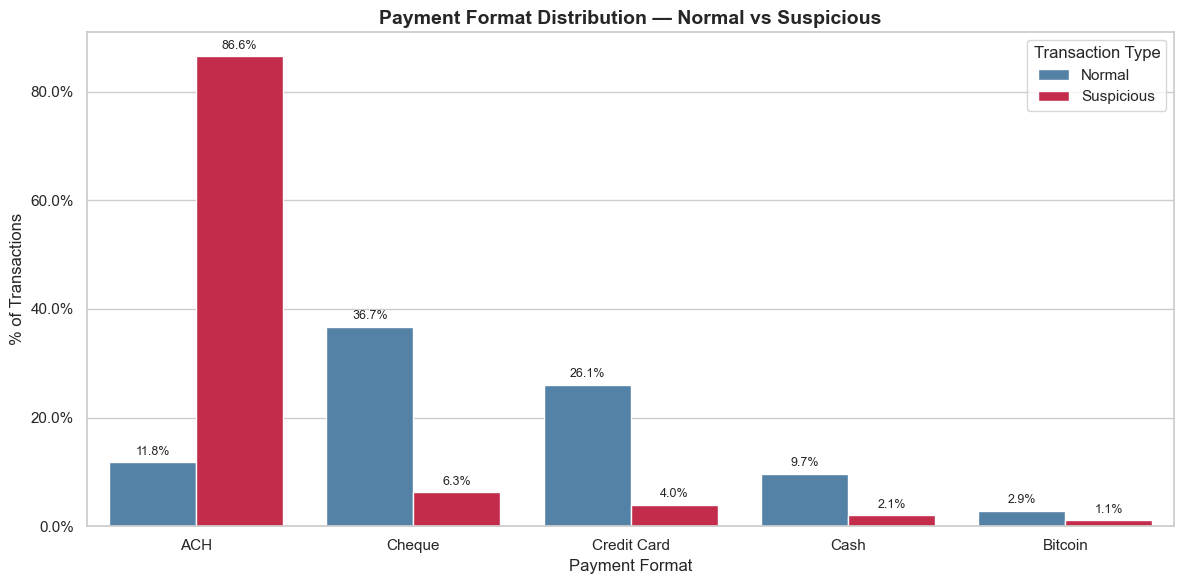

In [30]:
normal_fmt = normal['payment_format'].value_counts(normalize=True).mul(100).reset_index()
normal_fmt.columns = ['payment_format', 'pct']
normal_fmt['type'] = 'Normal'

suspicious_fmt = suspicious['payment_format'].value_counts(normalize=True).mul(100).reset_index()
suspicious_fmt.columns = ['payment_format', 'pct']
suspicious_fmt['type'] = 'Suspicious'

fmt_combined = pd.concat([normal_fmt, suspicious_fmt], ignore_index=True)

format_order = suspicious_fmt.sort_values('pct', ascending=False)['payment_format'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=fmt_combined, x='payment_format', y='pct',
            hue='type',
            palette={'Normal': 'steelblue', 'Suspicious': 'crimson'},
            order=format_order,
            ax=ax)

ax.set_title('Payment Format Distribution — Normal vs Suspicious',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Format')
ax.set_ylabel('% of Transactions')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend(title='Transaction Type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('../outputs/charts/03_payment_format.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight — Payment Format Distribution

The payment format breakdown reveals one dominant pattern:

- **ACH (Automated Clearing House)** is by far the most common 
  format for suspicious transactions at **86.6%** — despite only 
  accounting for **11.8%** of normal transactions. This is a 
  dramatic overrepresentation
- **Cheque** dominates normal transactions at **36.7%** but drops 
  to just **6.3%** in suspicious activity
- **Bitcoin**, despite its reputation as a high risk payment method, 
  accounts for only **1.1%** of suspicious transactions — lower than 
  its normal usage share of **2.9%**
- **Reinvestment** doesn't appear at all in suspicious transactions

> **AML takeaway:** ACH transfers are the payment method of choice 
> for money laundering in this dataset — not Bitcoin as commonly 
> assumed. ACH allows large, fast, automated transfers which makes 
> it ideal for moving large sums quickly. Any compliance team should 
> be paying close attention to high value ACH transactions.

---

### **4. Daily Suspicious Transactions Volume**

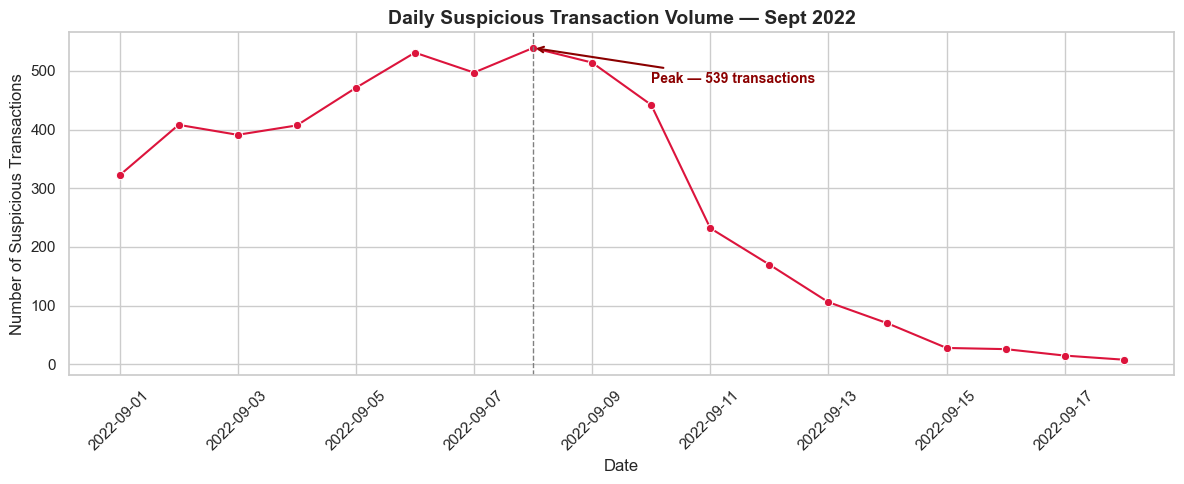

In [42]:
import datetime

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=daily, x='date', y='count', 
             marker='o', color='crimson', ax=ax)

ax.set_title('Daily Suspicious Transaction Volume — Sept 2022',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Suspicious Transactions')
ax.axvline(x=datetime.date(2022, 9, 8), color='gray', 
           linestyle='--', linewidth=1)
ax.annotate('Peak — 539 transactions', 
            xy=(datetime.date(2022, 9, 8), 539),
            xytext=(datetime.date(2022, 9, 10), 480),
            fontsize=10,
            color='darkred',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/charts/04_daily_suspicious_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight — Daily Suspicious Transaction Volume

The 18 day window reveals a clear pattern in suspicious activity:

- Suspicious transactions **built gradually** from 322 on Sept 1st, 
  peaking at **539 transactions on Sept 8th**
- After the peak there is a **sharp and consistent decline** — 
  dropping from 539 to just 8 transactions by Sept 18th
- The drop from Sept 10th onwards is too steep to be natural — 
  this is most likely because the **dataset ends on Sept 18th** 
  and the final days have incomplete data rather than a genuine 
  reduction in suspicious activity

> **AML takeaway:** The gradual build followed by a sharp peak 
> is consistent with a coordinated laundering campaign — activity 
> ramps up, peaks, then either gets detected and stopped or the 
> dataset simply ends. In a real investigation this pattern would 
> trigger an immediate look at what changed around Sept 8th.

---

## Conclusion — What Does This Tell Us About Money Laundering?

Analysing 5 million transactions with only 0.10% flagged as 
suspicious is exactly the kind of challenge a real AML analyst 
faces every day. Finding those 5,000 needles in the haystack 
requires knowing what to look for — and this analysis shows 
some clear patterns.

**What the data tells us:**

- **Transaction amounts** are one of the clearest indicators — 
  suspicious transactions are heavily concentrated at higher 
  values while normal transactions are more spread out across 
  a wider range. An unusually large transaction should always 
  raise a flag

- **Time of day** tells an interesting story despite the noise 
  in the normal transaction data. Suspicious activity peaks 
  during business hours — particularly around midday — which 
  suggests sophisticated laundering deliberately timed to blend 
  in with legitimate transaction volume rather than stand out

- **Payment format is the biggest red flag** — ACH transfers 
  account for 86.6% of all suspicious transactions despite 
  only making up 11.8% of normal activity. Contrary to popular 
  assumption, Bitcoin and cash are not the highest risk formats 
  in this dataset. Any compliance team should have enhanced 
  monitoring on high value ACH transfers

- **The daily trend** shows suspicious activity building to a 
  peak on September 8th before declining sharply. This kind of 
  pattern — a gradual ramp up followed by a sudden drop — is 
  consistent with a coordinated laundering campaign and would 
  be a priority for further investigation in a real world scenario

**The bottom line:**

> Money laundering does not always look the way you expect. 
> It hides in plain sight — using mainstream payment methods, 
> operating during business hours, and moving large amounts 
> that individually might not trigger automated rules. The 
> value of data analysis in AML is connecting those dots 
> before the money disappears.

---

*Data source: IBM Synthetic AML Dataset via Kaggle*
*Analysis covers 5,078,345 transactions across September 2022*
*0.10% flagged as suspicious — 5,177 transactions*